In [405]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [406]:
def sdt_p(dprime, c):
    """SDT mapping: criterion c and discriminability d' -> pm, pn."""
    pm = np.clip(norm.cdf(dprime / 2 - c), 1e-6, 1 - 1e-6)
    pn = np.clip(norm.cdf(-dprime / 2 - c), 1e-6, 1 - 1e-6)
    return pm, pn

In [407]:
d_prime = 2

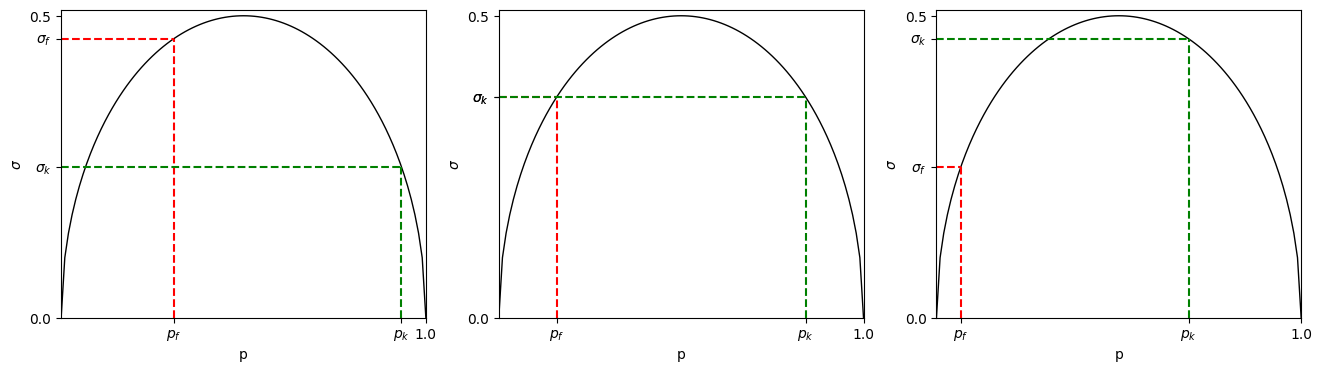

In [408]:

cs = [-0.5,0,0.5]

fig, axes = plt.subplots(1,3,figsize = (16,4))



for i in range(3):
    ax = axes[i]
    c = cs[i]
    pk, pf = sdt_p(d_prime, c)

    s_f = np.sqrt(pf*(1-pf))
    s_k = np.sqrt(pk*(1-pk))


    p = np.asarray([0.01*i for i in range(101)])
    sigma = np.sqrt(p*(1 - p))

    ax.plot(p, sigma,color = "black",linewidth=1)
    ax.vlines(pf, 0, s_f, color="red", linestyles="--")
    ax.vlines(pk, 0,s_k, color="green", linestyles="--")

    ax.hlines( s_f, 0,pf, color="red", linestyles="--")
    ax.hlines( s_k, 0,pk, color="green", linestyles="--")

    ax.set_xlabel("p")
    ax.set_ylabel(r"$\sigma$")
    ax.set_ylim(bottom=0,top=0.51)

    # Add pf, pk as extra ticks alongside the normal ones
    existing_ticks = [1.0]
    ax.set_xticks(list(existing_ticks) + [pf, pk])
    ax.set_xticklabels([f"{t:.1f}" for t in existing_ticks] + [r"$p_f$", r"$p_k$"])
    ax.set_xlim(0, 1)  # keep original range after adding ticks


    existing_ticks = [0.0,0.5]
    ax.set_yticks(list(existing_ticks) + [s_f, s_k])
    ax.set_yticklabels([f"{t:.1f}" for t in existing_ticks] + [r"$\sigma_f$", r"$\sigma_k$"])
    ax.set_ylim(0, 0.51)  # keep original range after adding ticks

plt.show()


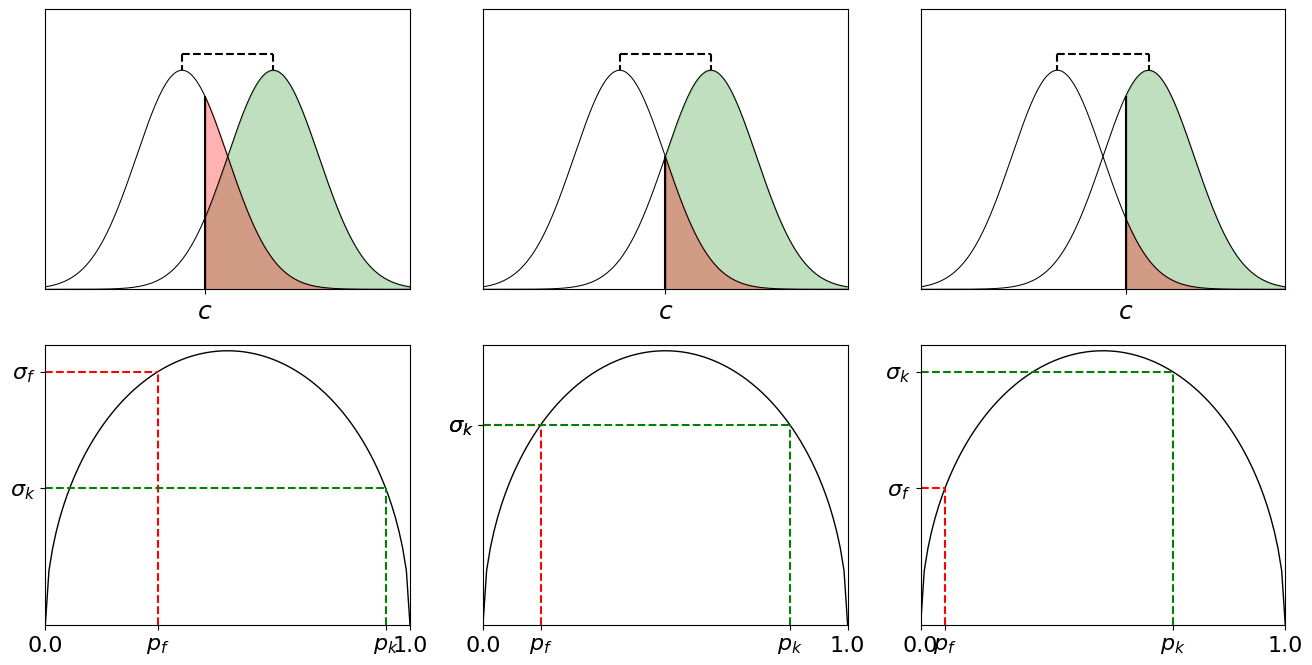

In [409]:





fig, axes = plt.subplots(2,3,figsize = (16,8))

plt_start,plt_slut = (-3,5)

for i in range(3):
    ax_s = axes[1,i]
    c = cs[i]
    pk, pf = sdt_p(d_prime, c)

    s_f = np.sqrt(pf*(1-pf))
    s_k = np.sqrt(pk*(1-pk))


    p = np.asarray([0.01*i for i in range(101)])
    sigma = np.sqrt(p*(1 - p))

    ax_s.plot(p, sigma,color = "black",linewidth=1)
    ax_s.vlines(pf, 0, s_f, color="red", linestyles="--")
    ax_s.vlines(pk, 0,s_k, color="green", linestyles="--")

    ax_s.hlines( s_f, 0,pf, color="red", linestyles="--")
    ax_s.hlines( s_k, 0,pk, color="green", linestyles="--")

    ax_s.set_ylim(bottom=0,top=0.51)

    # Add pf, pk as extra ticks alongside the normal ones
    existing_ticks = [0.0,1.0]
    ax_s.set_xticks(list(existing_ticks) + [pf, pk])
    ax_s.set_xticklabels([f"{t:.1f}" for t in existing_ticks] + [r"$p_f$", r"$p_k$"],fontsize = 16)
    ax_s.set_xlim(0, 1)  # keep original range after adding ticks


    existing_ticks = []
    ax_s.set_yticks(list(existing_ticks) + [s_f, s_k])
    ax_s.set_yticklabels([f"{t:.1f}" for t in existing_ticks] + [r"$\sigma_f$", r"$\sigma_k$"],fontsize = 16)
    ax_s.set_ylim(0, 0.51)  # keep original range after adding ticks




    ax_n = axes[0,i]
    c = cs[i]
    

    x_array = [0.01*i for i in range(plt_start*100,plt_slut*100 )]


    gauss_f = norm.pdf(x_array, loc=0, scale=1)
    gauss_k = norm.pdf(x_array, loc=d_prime, scale=1)



    ax_n.plot(x_array, gauss_k,color = "black",linewidth=0.75)
    filled_k_x = [x for x in x_array if x>d_prime/2 + c]
    filled_k_gauss = norm.pdf(filled_k_x, loc=d_prime, scale=1)
    ax_n.fill_between(filled_k_x,filled_k_gauss,color="green",alpha = 0.25)

    ax_n.plot(x_array, gauss_f,color = "black",linewidth=0.75)
    filled_f_x = [x for x in x_array if x>d_prime/2 + c]
    filled_f_gauss = norm.pdf(filled_f_x, loc=0, scale=1)
    ax_n.fill_between(filled_f_x,filled_f_gauss,color="red",alpha = 0.3)

    ax_n.vlines(d_prime/2 + c, 0, max(norm.pdf(d_prime/2 + c, loc=0, scale=1),norm.pdf(d_prime/2 + c, loc=d_prime, scale=1)), color="black",linewidth = 1.5)
    



    ax_n.set_ylim(bottom=0,top=1.0)
    ax_n.set_xlim(plt_start,plt_slut)
    ax_n.set_ylim(0.0,np.max(gauss_f)+0.1)

    # Add pf, pk as extra ticks alongside the normal ones
    existing_ticks = []
    ax_n.set_xticks(list(existing_ticks) + [d_prime/2 + c])
    ax_n.set_xticklabels([f"{t:.1f}" for t in existing_ticks] + [r"$c$"],fontsize=18)



    existing_ticks = []
    ax_n.set_yticks(list(existing_ticks))
    ax_n.set_yticklabels([f"{t:.1f}" for t in existing_ticks])
    ax_n.set_ylim(0, 0.51)  # keep original range after adding ticks

    ax_n.hlines(np.max(gauss_f)+0.03, 0.0, d_prime, color="black",linestyles="--")

    ax_n.vlines(d_prime,np.max(gauss_f)+0.03,np.max(gauss_f), color="black",linestyles="--")
    ax_n.vlines(0,np.max(gauss_f)+0.03,np.max(gauss_f), color="black",linestyles="--")


plt.show()

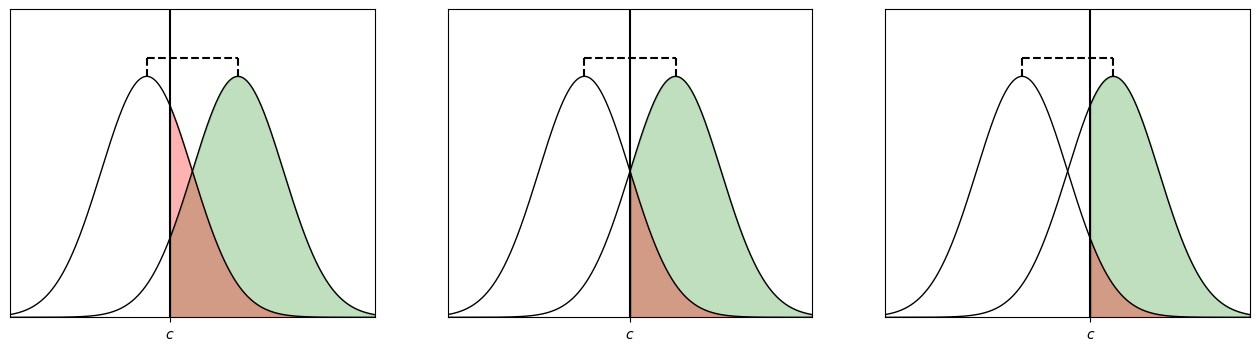

In [410]:





fig, axes = plt.subplots(1,3,figsize = (16,4))

plt_start,plt_slut = (-3,5)

for i in range(3):
    ax = axes[i]
    c = cs[i]
    

    x_array = [0.01*i for i in range(plt_start*100,plt_slut*100 )]


    gauss_f = norm.pdf(x_array, loc=0, scale=1)
    gauss_k = norm.pdf(x_array, loc=d_prime, scale=1)



    ax.plot(x_array, gauss_k,color = "black",linewidth=1)
    filled_k_x = [x for x in x_array if x>d_prime/2 + c]
    filled_k_gauss = norm.pdf(filled_k_x, loc=d_prime, scale=1)
    ax.fill_between(filled_k_x,filled_k_gauss,color="green",alpha = 0.25)

    ax.plot(x_array, gauss_f,color = "black",linewidth=1)
    filled_f_x = [x for x in x_array if x>d_prime/2 + c]
    filled_f_gauss = norm.pdf(filled_f_x, loc=0, scale=1)
    ax.fill_between(filled_f_x,filled_f_gauss,color="red",alpha = 0.3)

    ax.vlines(d_prime/2 + c, 0, 1, color="black")
    



    ax.set_ylim(bottom=0,top=1.0)
    ax.set_xlim(plt_start,plt_slut)
    ax.set_ylim(0.0,np.max(gauss_f)+0.1)

    # Add pf, pk as extra ticks alongside the normal ones
    existing_ticks = []
    ax.set_xticks(list(existing_ticks) + [d_prime/2 + c])
    ax.set_xticklabels([f"{t:.1f}" for t in existing_ticks] + [r"$c$"])



    existing_ticks = []
    ax.set_yticks(list(existing_ticks))
    ax.set_yticklabels([f"{t:.1f}" for t in existing_ticks])
    ax.set_ylim(0, 0.51)  # keep original range after adding ticks

    ax.hlines(np.max(gauss_f)+0.03, 0.0, d_prime, color="black",linestyles="--")

    ax.vlines(d_prime,np.max(gauss_f)+0.03,np.max(gauss_f), color="black",linestyles="--")
    ax.vlines(0,np.max(gauss_f)+0.03,np.max(gauss_f), color="black",linestyles="--")


plt.show()

In [411]:
def wald_pdf(t, v, s, B):
    """First-passage-time density of a Wald process with drift v,
    diffusion coefficient s, and threshold B."""
    t = np.asarray(t, dtype=float)
    out = np.zeros_like(t)
    ok = t > 0
    out[ok] = (B / np.sqrt(2 * np.pi * s ** 2 * t[ok] ** 3)) * \
              np.exp(-((v * t[ok] - B) ** 2) / (2 * s ** 2 * t[ok]))
    return out


def wald_cdf(t, v, s, B):
    """CDF of the same Wald process."""
    t = np.asarray(t, dtype=float)
    out = np.zeros_like(t)
    ok = t > 0
    ti = t[ok]
    sq = np.sqrt(ti)
    a1 = (v * ti - B) / (s * sq)
    a2 = (v * ti + B) / (s * sq)
    ev = np.clip(2 * B * v / s ** 2, None, 700)
    out[ok] = norm.cdf(a1) + np.exp(ev) * norm.cdf(-a2)
    return np.clip(out, 0, 1)

def defective_pdf(t, v_k,v_f, s_k,s_f, B, dt): 
    k_win = wald_pdf(t,v_k,s_k,B)*(1 - wald_cdf(t, v_f, s_f, B))
    f_win = wald_pdf(t,v_f,s_f,B)*(1 - wald_cdf(t, v_k, s_k, B))
    
    k_win_prop = np.sum(k_win*dt)
    f_win_prop = np.sum(f_win*dt)


    k_win = k_win/k_win_prop
    f_win = f_win/f_win_prop
    mean_rt_k = np.sum(k_win*t*dt)
    mean_rt_f = np.sum(f_win*t*dt)
    return mean_rt_k,mean_rt_f


In [412]:
cs = [0.01*i for i in range(-100,100)]

E_rt_k_list =[]
E_rt_f_list =[]

for c in cs:
    B = 0.3

    d_prime = 1
    p_k,p_f = sdt_p(d_prime,c) 
    s_k = np.sqrt(p_k*(1-p_k))
    s_f = np.sqrt(p_f*(1-p_f))
    v_f = p_f
    v_k = p_k
    t = np.linspace(0,10,10000)

    mean_rt_k,mean_rt_f = defective_pdf(t, v_k,v_f, s_k,s_f, B,10/10000)

    E_rt_k_list.append(mean_rt_k)
    E_rt_f_list.append(mean_rt_f)



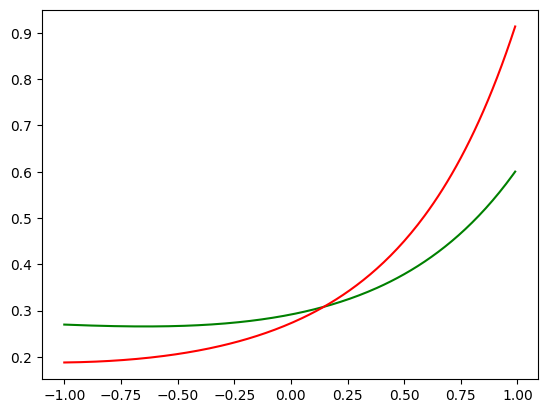

In [413]:
plt.plot(cs,E_rt_k_list,color = "green")
plt.plot(cs,E_rt_f_list,color = "red")

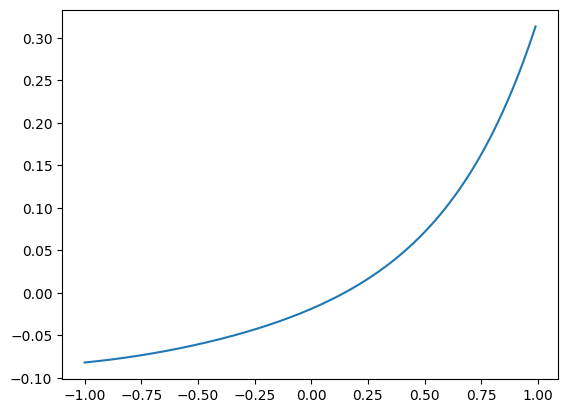

In [414]:
diff_E = np.asarray(E_rt_f_list) - np.asarray(E_rt_k_list)
plt.plot(cs,diff_E)